1. CARREGANDO BANCO DE DADOS

In [1]:
file.exists("/content/exportacao_cargas.csv.gz")

[1] TRUE

2. LENDO O BANCO DE DADOS E CRIANDO O OBJETO

In [2]:
dados <- read.csv(
  "/content/exportacao_cargas.csv.gz",
  header = TRUE,
  sep = ","
)

3. CONFERINDO SE O BANCO DE DADOS FOI CARREGADO CORRETAMENTE

In [3]:
dim(dados)

[1] 1097014      16

4. VENDO ALGUMAS LINHAS

In [4]:
head(dados)

,TOTAL_TEU,NUMERO_VIAGEM,TIPO_NAVEGACAO,MOVIMENTO,ANO,TERMINAIS,TOTAL_TONELADAS,NATUREZA_CARGA,TOTAL_UNID,MES,CLASSENAVIO,SENTIDO,TIPO_INSTALACAO,BERCOS,MERCADORIAS,ANO_MES
,<int>,<int>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,92,4659,LONGO CURSO,CONVENCIONAL,2012,SANTOS BRASIL,"1504,855",CARGA CONTEINERIZADA,76,11,PORTA-CONTAINERS,DESEMBARQUE,PORTO ORGANIZADO,SBR 2,PRODUTOS QUÍMICOS ORGÂNICOS,2012-11-01
2,28,3888,LONGO CURSO,REMOÇÃO,2012,SANTOS BRASIL,"190,55",CARGA CONTEINERIZADA,14,10,PORTA-CONTAINERS,EMBARQUE,PORTO ORGANIZADO,SBR 3,OUTRAS MERCADORIAS,2012-10-01
3,598,4731,CABOTAGEM,CONVENCIONAL,2012,SANTOS BRASIL,"5631,35",CARGA CONTEINERIZADA,335,10,PORTA-CONTAINERS,DESEMBARQUE,PORTO ORGANIZADO,SBR 2,OUTRAS MERCADORIAS,2012-10-01
4,30,4646,LONGO CURSO,CONVENCIONAL,2012,SANTOS BRASIL,"596,37",CARGA CONTEINERIZADA,24,11,PORTA-CONTAINERS,EMBARQUE,PORTO ORGANIZADO,SBR 3,SUCOS CÍTRICOS,2012-11-01
5,317,5010,LONGO CURSO,CONVENCIONAL,2012,ECOPORTO,"4601,841",CARGA CONTEINERIZADA,227,11,PORTA-CONTAINERS,EMBARQUE,PORTO ORGANIZADO,ECOP 1,OUTRAS MERCADORIAS,2012-11-01
6,14,4856,LONGO CURSO,CONVENCIONAL,2012,SANTOS BRASIL,"276,87",CARGA CONTEINERIZADA,14,11,PORTA-CONTAINERS,DESEMBARQUE,PORTO ORGANIZADO,SBR 2,PRODUTOS QUÍMICOS ORGÂNICOS,2012-11-01


6. CONFERINDO NOME DAS VARIÁVEIS

In [5]:
names(dados)

[1] "TOTAL_TEU"       "NUMERO_VIAGEM"   "TIPO_NAVEGACAO"  "MOVIMENTO"      
 [5] "ANO"             "TERMINAIS"       "TOTAL_TONELADAS" "NATUREZA_CARGA" 
 [9] "TOTAL_UNID"      "MES"             "CLASSENAVIO"     "SENTIDO"        
[13] "TIPO_INSTALACAO" "BERCOS"          "MERCADORIAS"     "ANO_MES"

7. SELECIONANDO SOMENTE CARGA CONTERIZADA

In [7]:
dados_reg <- subset(
  dados,
  NATUREZA_CARGA == "CARGA CONTEINERIZADA"
)

8. MANTENDO SOMENTE AS 3 VARIÁVEIS NECESSÁRIAS

In [8]:
dados_reg <- dados_reg[, c(
  "TOTAL_TONELADAS",
  "TOTAL_TEU",
  "TOTAL_UNID"
)]

9. GARANTINDO QUE AS DUAS VARIÁVEIS SEJAM NUMÉRICAS

In [13]:
dados_reg$TOTAL_TONELADAS <- as.numeric(dados_reg$TOTAL_TONELADAS)

dados_reg$TOTAL_TEU <- as.numeric(dados_reg$TOTAL_TEU)

Warning message:
“NAs introduced by coercion”


10. VERIFICANDO SE APARECEM VALORES INVÁLIDOS

In [14]:
sum(is.na(dados_reg$TOTAL_TONELADAS))
sum(is.na(dados_reg$TOTAL_TEU))

[1] 45213

[1] 0

11. REFIRANDO VALORES INVÁLIDOS

In [15]:
dados_reg <- dados_reg[
  is.finite(dados_reg$TOTAL_TONELADAS) &
  is.finite(dados_reg$TOTAL_TEU),
]

12. CONFERINDO

In [16]:
summary(dados_reg[, c(
  "TOTAL_TONELADAS",
  "TOTAL_TEU"
)])

 TOTAL_TONELADAS     TOTAL_TEU      
 Min.   :    2.0   Min.   :   1.00  
 1st Qu.:   29.0   1st Qu.:   2.00  
 Median :  100.0   Median :   8.00  
 Mean   :  674.1   Mean   :  64.09  
 3rd Qu.:  418.0   3rd Qu.:  38.00  
 Max.   :34004.0   Max.   :3291.00  

13. CONFERINDO OS DADOS

In [9]:
head(dados_reg)

,TOTAL_TONELADAS,TOTAL_TEU,TOTAL_UNID
,<chr>,<int>,<int>
1,"1504,855",92,76
2,"190,55",28,14
3,"5631,35",598,335
4,"596,37",30,24
5,"4601,841",317,227
6,"276,87",14,14


14. BOOTSTRAP COM AMOSTRA ALEATÓRIA DE 50.000 REGISTROS

In [10]:
set.seed(1)

dados_reg <- dados_reg[
  sample(nrow(dados_reg), 50000),
]

15. CONFERINDO SE ESTÁ LENDO APENAS AS 50.OOO LINHAS E 3 COLUNAS

In [11]:
dim(dados_reg)

[1] 50000     3

16. REGRESSÃO SIMPLES

In [17]:
m1 <- lm(
  TOTAL_TONELADAS ~ TOTAL_TEU,
  data = dados_reg
)

17. REGRESSÃO MÚLTIPLA

In [33]:
m2 <- lm(
  TOTAL_TONELADAS ~ TOTAL_TEU + TOTAL_UNID,
  data = dados_reg
)

18. VALIDAÇÃO CRUZADA (5 PARTES)

In [34]:
cv5 <- function(formula, data) {

  k <- 5

  grupos <- sample(rep(1:k, length.out = nrow(data)))

  erros <- numeric(k)

  for (j in 1:k) {

    treino <- data[grupos != j, ]
    teste <- data[grupos == j, ]

    m <- lm(formula, data = treino)

    previsao <- predict(m, newdata = teste)

    erros[j] <- mean(
      (teste$TOTAL_TONELADAS - previsao)^2
    )
  }

  mean(erros)
}

19. CV5 DO MODELO 1

In [20]:
cv_m1 <- cv5(
  TOTAL_TONELADAS ~ TOTAL_TEU,
  dados_reg
)

cv_m1

[1] 1681197

20. CV5 DO MODELO 2

In [21]:
cv_m2 <- cv5(
  TOTAL_TONELADAS ~ TOTAL_TEU + TOTAL_UNID,
  dados_reg
)

cv_m2

[1] 1602170

21. COMPARANDO OS 2 MODELOS

In [22]:
c(
  Modelo_1 = cv_m1,
  Modelo_2 = cv_m2
)

Modelo_1 Modelo_2 
 1681197  1602170

22. DESCOBRINDO QUAL MODELO TEVE MENOR CV5

In [23]:
if (cv_m1 < cv_m2) {
  print("Modelo 1 apresentou menor CV5")
} else {
  print("Modelo 2 apresentou menor CV5")
}

[1] "Modelo 2 apresentou menor CV5"


23. DEIXANDO O RESULTADO ORGANIZADO

In [24]:
resultado_cv <- data.frame(
  Modelo = c(
    "Modelo 1",
    "Modelo 2"
  ),
  CV5 = c(
    cv_m1,
    cv_m2
  )
)

resultado_cv

Modelo,CV5
<chr>,<dbl>
Modelo 1,1681197
Modelo 2,1602170


24. COEFICIENTE MODELO 1

In [25]:
coef(m1)

(Intercept)   TOTAL_TEU 
 113.322806    8.749078

25. COEFICIENTE MODELO 2

In [26]:
coef(m2)

(Intercept)   TOTAL_TEU  TOTAL_UNID 
 77.1772837  -0.4776425  14.8862014

26. MODELO NO QUAL TEVE O MENOR CV5

In [35]:
#MODELO 2
modelo_escolhido <- m2

27. BOOTSTRAP DO MODELO ESCOLHIDO

In [28]:
#MODELO 2
set.seed(1)

b <- replicate(
  2000,
  {
    i <- sample(
      nrow(dados_reg),
      nrow(dados_reg),
      replace = TRUE
    )

    coef(
      lm(
        TOTAL_TONELADAS ~ TOTAL_TEU + TOTAL_UNID,
        data = dados_reg[i, ]
      )
    )["TOTAL_TEU"]
  }
)

28. CACULANDO O ERRO PADRÃO DO BOOTSTRAP

In [29]:
sd(b)

[1] 3.318079

29. CALCULANDO O INTERVALO DE 95%

In [36]:
quantile(
  b,
  c(0.025, 0.975)
)

2.5%     97.5% 
-7.701295  5.224132

30. TUDO EM UMA ÚNICA SAÍDA

In [31]:
c(
  ep = sd(b),
  quantile(b, c(0.025, 0.975))
)

ep      2.5%     97.5% 
 3.318079 -7.701295  5.224132

INTERVALO CONTÉM ZERO = O intervalo de confiança bootstrap de 95% para o coeficiente de TOTAL_TEU contém zero. Portanto, dentro deste procedimento, o coeficiente não é distinguível de zero.

31. GRÁFICO DO BOOTSTRAP

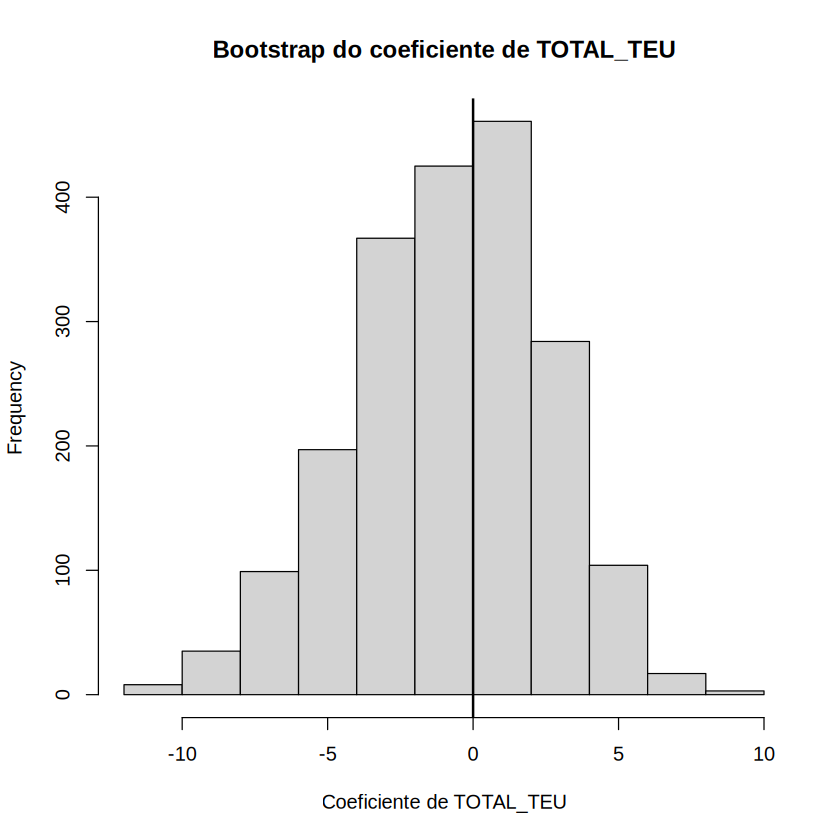

In [32]:
hist(
  b,
  main = "Bootstrap do coeficiente de TOTAL_TEU",
  xlab = "Coeficiente de TOTAL_TEU"
)

abline(
  v = 0,
  lwd = 2
)